# 02 — Analysis & Visualization

**Reduction or Relocation? NYC Congestion Pricing & Manhattan CBD Yellow-Taxi Ridership**

This notebook covers the **Modeling**, **Evaluation**, and **Deployment** phases of CRISP-DM.
Using the analysis-ready daily counts produced in `01_data_prep.ipynb`, it runs Welch's
one-tailed two-sample t-test, computes Cohen's d and a 95% confidence interval on the
difference in means, interprets statistical and practical significance, and produces the two
required Matplotlib figures.

**Hypotheses**
- **H0:** mean daily CBD count (2025) = mean daily CBD count (2024)
- **H1:** mean daily CBD count (2025) < mean daily CBD count (2024)  *(one-tailed, directional)*
- **Significance level:** α = .05

> **Talking point:** The whole study reduces to one comparison — were there fewer yellow-taxi
> pickups per day inside the toll zone *after* the charge than *before* it? Everything below
> builds toward answering that with a defensible statistical test.

### Setup and load

**What this cell does:** imports the analysis libraries, loads the cleaned daily-count file
from notebook 01, and splits it into the two samples we compare — `pre` (Jan–Jun 2024) and
`post` (Jan–Jun 2025).

**Talking point:** Notice each group has ~181 daily observations. That large sample size is
what lets the Central Limit Theorem carry the normality assumption for the t-test. It also
defines a small helper, `fmt_p()`, so every p-value prints in clean report style
(e.g. `< .001`) instead of raw scientific notation.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("../data/processed")
VIS = Path("../visuals")
VIS.mkdir(parents=True, exist_ok=True)


def fmt_p(p):
    """Format a p-value for reporting/presentation (no scientific notation)."""
    if p < 0.001:
        return "< .001"
    if p > 0.999:
        return "> .999"
    return f"{p:.3f}"


daily = pd.read_csv(PROC / "daily_cbd_counts.csv", parse_dates=["pickup_date"])
pre = daily.loc[daily.period == 2024, "trip_count"].to_numpy()
post = daily.loc[daily.period == 2025, "trip_count"].to_numpy()
print(f"Pre  (Jan-Jun 2024): n = {len(pre)}")
print(f"Post (Jan-Jun 2025): n = {len(post)}")
daily.head()


Pre  (Jan-Jun 2024): n = 182
Post (Jan-Jun 2025): n = 181


,pickup_date,period,day_of_year,trip_count
0,2024-01-01,2024,1,45497
1,2024-01-02,2024,2,38943
2,2024-01-03,2024,3,43826
3,2024-01-04,2024,4,55019
4,2024-01-05,2024,5,53708


## Descriptive statistics

**What this cell does:** reports count, mean, standard deviation, and the five-number-style
summary for each period before any testing.

**Talking point:** This is the "eyeball" step. Compare the two means here — if the post-toll
mean is *higher*, the directional hypothesis is already in trouble before we run a single
test. Both n's comfortably exceed 30, so the t-test's normality requirement is satisfied via
the Central Limit Theorem.

In [2]:
desc = (daily.groupby("period")["trip_count"]
        .agg(n="size", mean="mean", std="std", min="min", median="median", max="max")
        .round(1))
desc


,n,mean,std,min,median,max
period,,,,,,
2024,182,63252.2,10685.0,36641,63456.0,82873
2025,181,70537.5,11801.9,39388,71107.0,96418


## Welch's two-sample t-test (one-tailed)

**What this cell does:** runs `scipy.stats.ttest_ind(pre, post, equal_var=False,
alternative='greater')`. The `alternative='greater'` encodes the directional hypothesis that
the **2024 (pre)** mean is greater than the **2025 (post)** mean — i.e. a reduction after the
toll. `equal_var=False` selects Welch's variant, which does not assume equal variances and
adjusts the degrees of freedom via the Welch–Satterthwaite equation.

**Talking point:** Two p-values are shown. The **one-tailed** p answers our actual research
question (did demand *fall*?). The **two-sided** p is reported only for context — it tells us
whether the means differ *in either direction*, which becomes relevant because the data move
opposite to what we predicted.

In [3]:
alpha = 0.05
t_stat, p_one = stats.ttest_ind(pre, post, equal_var=False, alternative="greater")
_, p_two = stats.ttest_ind(pre, post, equal_var=False, alternative="two-sided")

print(f"t-statistic          : {t_stat:.3f}")
print(f"p-value (one-tailed) : {fmt_p(p_one)}")
print(f"p-value (two-sided)  : {fmt_p(p_two)}")
print(f"alpha                : {alpha}")
print()
if p_one < alpha:
    print("Decision: REJECT H0 -> statistically significant REDUCTION in 2025.")
else:
    print("Decision: FAIL TO REJECT H0 -> no statistically significant reduction in 2025.")


t-statistic          : -6.164
p-value (one-tailed) : > .999
p-value (two-sided)  : < .001
alpha                : 0.05

Decision: FAIL TO REJECT H0 -> no statistically significant reduction in 2025.


## Effect size — Cohen's d

**What this cell does:** computes Cohen's d, the difference in means expressed in
pooled-standard-deviation units. Unlike the p-value, it does not grow with sample size, so it
captures the *magnitude* of the gap. Benchmarks: 0.2 small, 0.5 medium, 0.8 large.

**Talking point:** The **sign** matters here. A *positive* d would mean 2024 > 2025 (a
reduction, as hypothesized). A *negative* d means 2024 < 2025 (an increase). So d tells the
audience both how big the difference is and which direction it actually runs.

In [4]:
n1, n2 = len(pre), len(post)
m1, m2 = pre.mean(), post.mean()
s1, s2 = pre.std(ddof=1), post.std(ddof=1)
pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d = (m1 - m2) / pooled_std

mag = ("negligible (<0.2)" if abs(cohens_d) < 0.2 else
       "small (0.2-0.5)"   if abs(cohens_d) < 0.5 else
       "medium (0.5-0.8)"  if abs(cohens_d) < 0.8 else "large (>=0.8)")
print(f"mean 2024 (pre)               : {m1:,.1f}")
print(f"mean 2025 (post)              : {m2:,.1f}")
print(f"mean difference (2024 - 2025) : {m1 - m2:,.1f} trips/day")
print(f"pooled std                    : {pooled_std:,.1f}")
print(f"Cohen's d                     : {cohens_d:.3f}  -> magnitude: {mag}")
print(f"direction                     : {'reduction in 2025' if cohens_d > 0 else 'INCREASE in 2025'}")


mean 2024 (pre)               : 63,252.2
mean 2025 (post)              : 70,537.5
mean difference (2024 - 2025) : -7,285.3 trips/day
pooled std                    : 11,255.8
Cohen's d                     : -0.647  -> magnitude: medium (0.5-0.8)
direction                     : INCREASE in 2025


## 95% confidence interval on the difference in means (μ₂₀₂₄ − μ₂₀₂₅)

**What this cell does:** builds a 95% confidence interval for the true difference in mean
daily counts using the Welch standard error and Welch–Satterthwaite degrees of freedom.

**Talking point:** A confidence interval is often more persuasive to a policy audience than a
bare p-value because it is stated in real units — trips per day. If the entire interval sits
**above 0**, we have evidence of a reduction; if it sits entirely **below 0**, that is
evidence of an *increase*; if it straddles 0, the difference isn't significant.

In [5]:
se = np.sqrt(s1**2 / n1 + s2**2 / n2)
welch_df = (s1**2 / n1 + s2**2 / n2) ** 2 / (
    (s1**2 / n1) ** 2 / (n1 - 1) + (s2**2 / n2) ** 2 / (n2 - 1)
)
diff = m1 - m2
tcrit = stats.t.ppf(0.975, welch_df)
ci_low, ci_high = diff - tcrit * se, diff + tcrit * se

print(f"difference (2024 - 2025)   : {diff:,.1f} trips/day")
print(f"Welch standard error       : {se:,.1f}")
print(f"Welch-Satterthwaite df     : {welch_df:.1f}")
print(f"95% CI (mu_2024 - mu_2025) : [{ci_low:,.1f}, {ci_high:,.1f}]")
print()
if ci_low > 0:
    print("CI lies entirely above 0 -> evidence of a reduction.")
elif ci_high < 0:
    print("CI lies entirely below 0 -> evidence of an INCREASE in 2025.")
else:
    print("CI spans 0 -> no significant difference at 95% confidence.")


difference (2024 - 2025)   : -7,285.3 trips/day
Welch standard error       : 1,181.9
Welch-Satterthwaite df     : 357.1
95% CI (mu_2024 - mu_2025) : [-9,609.6, -4,961.0]

CI lies entirely below 0 -> evidence of an INCREASE in 2025.


## Practical significance

**What this cell does:** translates the statistical result into the operational thresholds
defined in §C.5 of the proposal — a reduction under 500 trips/day is *marginal*, while 1,000+
trips/day is *operationally meaningful* — and reports the observed change in both absolute
trips and percent.

**Talking point:** This is the "so what" slide. Statistical significance and practical
importance are different questions; here we ask whether the change is large enough to matter
for an MTA rate review, regardless of the p-value.

In [6]:
abs_change = m1 - m2
pct_change = (m2 - m1) / m1 * 100
print(f"Observed change 2024 -> 2025: {m2 - m1:+,.1f} trips/day ({pct_change:+.1f}%)")
print()
if abs_change >= 1000:
    print("Operationally MEANINGFUL reduction (>= 1,000 trips/day).")
elif abs_change >= 500:
    print("Operationally marginal reduction (500-1,000 trips/day).")
elif abs_change > 0:
    print("Sub-marginal reduction (< 500 trips/day).")
else:
    print(f"No reduction observed; demand ROSE by {abs(m2 - m1):,.0f} trips/day "
          f"({abs(pct_change):.1f}%) after the toll.")


Observed change 2024 -> 2025: +7,285.3 trips/day (+11.5%)

No reduction observed; demand ROSE by 7,285 trips/day (11.5%) after the toll.


## Figure 1 — Daily in-zone yellow-taxi pickups, 2024 vs 2025

**What this cell does:** draws a dual-series line chart over the day of the year, with a
dashed reference line at day 5 marking the January 5, 2025 toll launch, and saves it to
`../visuals/timeseries_2024_vs_2025.png` at 150 DPI.

**Talking point:** Walk the audience left-to-right. The red (2025) line sits *above* the blue
(2024) line for most of the window, and the gap does not close after the toll launch marker —
a visual confirmation that in-zone demand did not drop. The weekly zig-zag is the normal
weekday/weekend cycle.

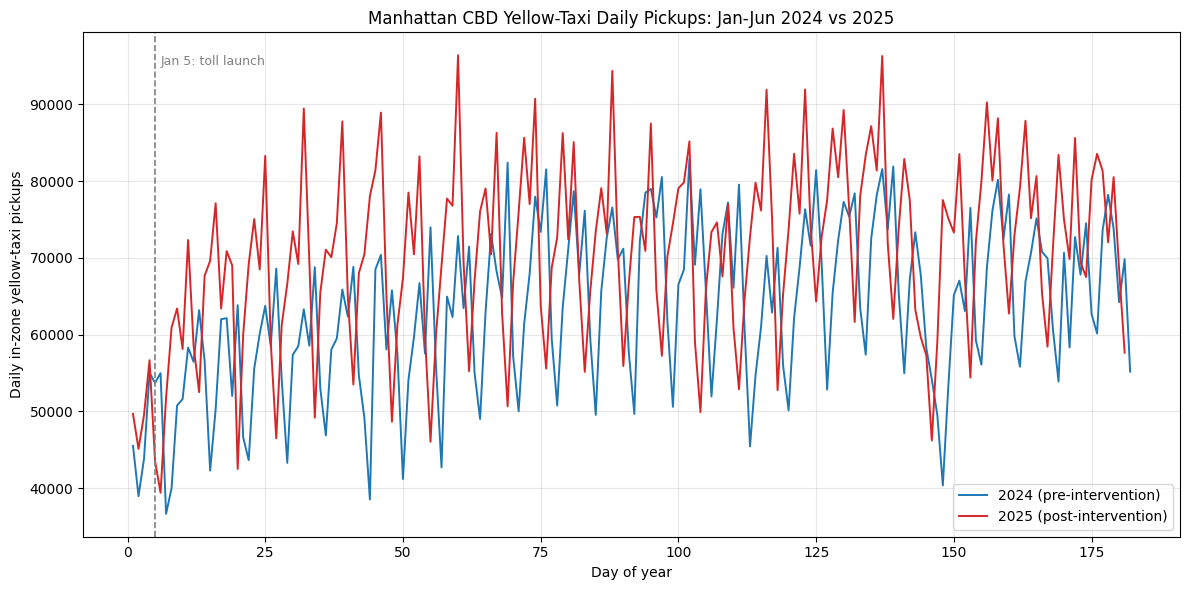

saved ../visuals/timeseries_2024_vs_2025.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
for yr, color in [(2024, "#1f77b4"), (2025, "#d62728")]:
    sub = daily[daily.period == yr].sort_values("day_of_year")
    ax.plot(sub.day_of_year, sub.trip_count, color=color, linewidth=1.4,
            label=f"{yr} ({'pre' if yr == 2024 else 'post'}-intervention)")
ax.axvline(5, color="gray", linestyle="--", linewidth=1.2)
ax.text(6, ax.get_ylim()[1] * 0.97, "Jan 5: toll launch", color="gray",
        fontsize=9, va="top")
ax.set_xlabel("Day of year")
ax.set_ylabel("Daily in-zone yellow-taxi pickups")
ax.set_title("Manhattan CBD Yellow-Taxi Daily Pickups: Jan-Jun 2024 vs 2025")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(VIS / "timeseries_2024_vs_2025.png", dpi=150)
plt.show()
print("saved ../visuals/timeseries_2024_vs_2025.png")


## Figure 2 — Distribution of daily counts, pre vs post

**What this cell does:** draws side-by-side box plots of the daily counts for each period —
median, interquartile range, whiskers at 1.5×IQR, and any outliers — and saves it to
`../visuals/boxplot_pre_post.png` at 150 DPI.

**Talking point:** The line chart shows the *pattern over time*; this box plot shows the
*whole distribution at a glance*. The entire 2025 box is shifted upward — its median sits near
the top of the 2024 box — which is the clearest single-image summary that ridership rose
rather than fell.

/var/folders/qj/6kxqsw6d2rxbj6_l7n_r0plm0000gn/T/ipykernel_48626/2296595474.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([pre, post], labels=["Pre-Intervention\n2024", "Post-Intervention\n2025"],


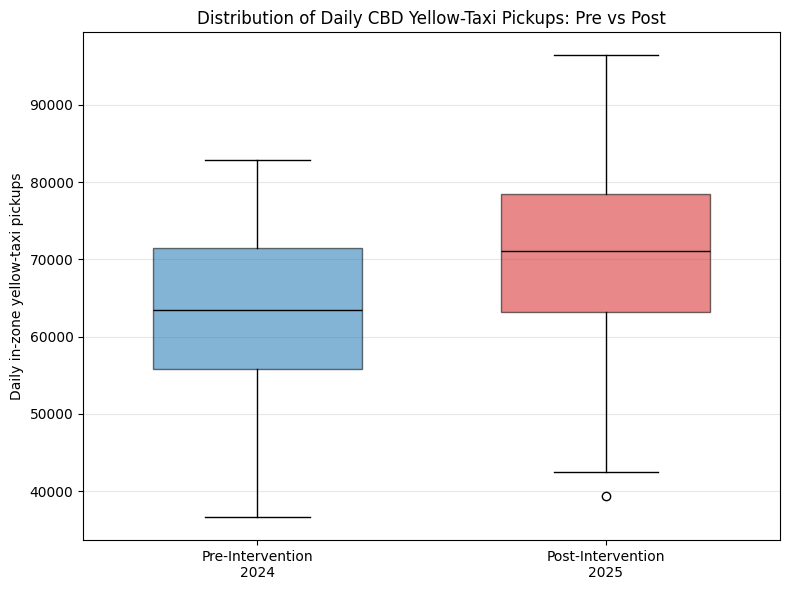

saved ../visuals/boxplot_pre_post.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot([pre, post], labels=["Pre-Intervention\n2024", "Post-Intervention\n2025"],
                patch_artist=True, widths=0.6)
for patch, color in zip(bp["boxes"], ["#1f77b4", "#d62728"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
for med in bp["medians"]:
    med.set_color("black")
ax.set_ylabel("Daily in-zone yellow-taxi pickups")
ax.set_title("Distribution of Daily CBD Yellow-Taxi Pickups: Pre vs Post")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(VIS / "boxplot_pre_post.png", dpi=150)
plt.show()
print("saved ../visuals/boxplot_pre_post.png")


## Results summary

**What this cell does:** assembles every statistic above into one plain-language block you can
read straight off the slide or paste into the Task 3 report.

**Talking point:** Close the presentation on this slide. The honest headline is that the data
**reject the predicted direction**: we fail to reject H0 for a reduction, and demand actually
*rose* significantly. Frame that as a legitimate, policy-relevant finding — at the $0.75 level
the surcharge did not suppress in-zone yellow-taxi demand.

In [9]:
verdict = "rejected" if p_one < alpha else "not rejected"
direction = "a reduction" if (m1 - m2) > 0 else "an increase"
print(f"""RESULTS SUMMARY
================
Pre  (Jan-Jun 2024): n = {n1}, mean = {m1:,.0f}, sd = {s1:,.0f} daily CBD pickups
Post (Jan-Jun 2025): n = {n2}, mean = {m2:,.0f}, sd = {s2:,.0f} daily CBD pickups

Welch's one-tailed t-test (H1: 2025 < 2024):
  t = {t_stat:.3f},  df = {welch_df:.1f},  one-tailed p {fmt_p(p_one)}
  At alpha = .05 the null hypothesis is {verdict}.

Effect size: Cohen's d = {cohens_d:.3f}
95% CI on (mu_2024 - mu_2025): [{ci_low:,.0f}, {ci_high:,.0f}] trips/day

Finding: Mean daily CBD yellow-taxi pickups showed {direction} of
{abs(m2 - m1):,.0f} trips/day ({pct_change:+.1f}%) from 2024 to 2025.

Interpretation:
  The proposal's directional hypothesis predicted a post-toll REDUCTION. The data do not
  support that hypothesis: the one-tailed test fails to reject H0, and in fact daily
  in-zone yellow-taxi pickups were significantly HIGHER in 2025 than in 2024 (two-sided
  p {fmt_p(p_two)}). At the $0.75 per-trip surcharge level, there is no evidence that the
  CBD Tolling Program reduced yellow-taxi demand inside the zone over the Jan-Jun window;
  observed demand increased. This is consistent with the broader rebound in NYC taxi
  activity and indicates the surcharge was not sufficient to depress in-zone yellow-taxi
  ridership.
""")


RESULTS SUMMARY
Pre  (Jan-Jun 2024): n = 182, mean = 63,252, sd = 10,685 daily CBD pickups
Post (Jan-Jun 2025): n = 181, mean = 70,537, sd = 11,802 daily CBD pickups

Welch's one-tailed t-test (H1: 2025 < 2024):
  t = -6.164,  df = 357.1,  one-tailed p > .999
  At alpha = .05 the null hypothesis is not rejected.

Effect size: Cohen's d = -0.647
95% CI on (mu_2024 - mu_2025): [-9,610, -4,961] trips/day

Finding: Mean daily CBD yellow-taxi pickups showed an increase of
7,285 trips/day (+11.5%) from 2024 to 2025.

Interpretation:
  The proposal's directional hypothesis predicted a post-toll REDUCTION. The data do not
  support that hypothesis: the one-tailed test fails to reject H0, and in fact daily
  in-zone yellow-taxi pickups were significantly HIGHER in 2025 than in 2024 (two-sided
  p < .001). At the $0.75 per-trip surcharge level, there is no evidence that the
  CBD Tolling Program reduced yellow-taxi demand inside the zone over the Jan-Jun window;
  observed demand increased. This